In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
X, y = mnist.data, mnist.target
print("x:", X)
print("y", y)
print(X.shape, "\n")
print(y.shape)

x: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
y ['5' '0' '4' ... '4' '5' '6']
(70000, 784) 

(70000,)


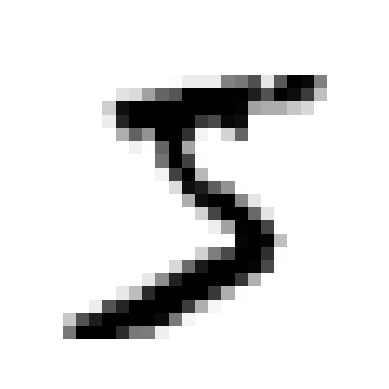

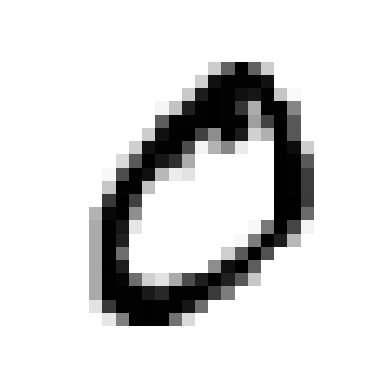

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

In [ ]:
# Take a look on data
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # cmap="binary" to get a grayscale color map
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()
# where 0 is white and 255 is black
print(X[0])
# It's looks like a five, if we take a look on "y" we see a 5
print(y[0])

In [3]:
# Training and test set (it's already is splitted and shuffled)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
# 70 000 всего 60 000 train, 10 000 test

In [4]:
from sklearn.linear_model import SGDClassifier

# Training a Binary Classifier

# [True, False, False, True, False] boolean mask
# Тут создатся массив по длине как y_train но со значениями True или False
# то есть там где равно 5 будет true, в других местах false
y_train_5 = y_train == "5"  # True for all 5s, False for all other digits
y_test_5 = y_test == "5"

# Мы даем фичи и лейблы чтобы SGDClassifier мог определять
# Исходя из лейблов к фичам что будет означать тот или иной ответ
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
# X0 =5, X1 = 0
sgd_clf.predict([X[0], X[1]])


array([ True, False])

## Performance Measures

In [5]:
# Measuring Accuracy Using Cross-Validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# Точность 95%

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier

# DummyClassifier предсказывает самый частый класс. 
# True  = цифра 5
# False = не 5
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# any(...) проверяет Есть ли хотя бы один True?
print(any(dummy_clf.predict(X_train)))
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# over 90%
# Можно иметь высокую accuracy,
# даже если модель вообще никогда не находит пятёрки.
# because only about 10% of the images are 5s
# This demonstrates why accuracy is generally not the preferred 
# performance measure for classifiers

# A much better way to evaluate the
# performance of a classifier is to look at the confusion matrix (CM).

False


array([0.90965, 0.90965, 0.90965])

In [ ]:
# IMPLEMENTING CROSS-VALIDATION

# custom cross validation, make same thing like Scikit-Learn 

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone 

skflods = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is not already shuffled
# делим на 3 части и сохраняем одинаковое соотношение классов
# 10% = True (5) ; 90% = False (не 5)

for train_index, test_index in skflods.split(X_train, y_train_5):
	clone_clf = clone(sgd_clf) 	# new empty model exact params, weights not copied 
	X_train_folds = X_train[train_index]
	y_train_folds = y_train_5[train_index]
	X_test_fold = X_train[test_index]
	y_test_fold = y_train_5[test_index]

	clone_clf.fit(X_train_folds, y_train_folds) # only on train
	y_pred = clone_clf.predict(X_test_fold) # predict on test fold
	n_correct = sum(y_pred == y_test_fold)
	print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [6]:
# Confusion Matrices
from sklearn.metrics import confusion_matrix
# cross_val_predict генерирует предсказания для каждого объекта так, 
# будто модель этот объект раньше не видела.
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)

# [0][0] = 53892 True Negative (TN)
# реально был 0 (это не 5),
# и модель тоже предсказала 0 (это не 5)

# [0][1] = 687 False Positive (FP)
# реально был 0 (это не 5),
# но модель ошибочно предсказала 1 (это 5)

# [1][0] = 1891 False Negative (FN)
# реально был 1 (это 5),
# но модель ошибочно предсказала 0 (это не 5)

# [1][1] = 3530 True Positive (TP)
# реально был 1 (это 5),
# и модель правильно предсказала 1 (это 5)

# perfect classifier 
y_train_perfect_predictions = y_train_5
cm_perfect = confusion_matrix(y_train_5, y_train_perfect_predictions)
print(cm_perfect)

[[53892   687]
 [ 1891  3530]]
[[54579     0]
 [    0  5421]]


In [ ]:
# Confusion Matrices example
from sklearn.metrics import confusion_matrix

y_true_example = [0, 0, 1, 1, 1, 0]
y_pred_example = [0, 1, 1, 0, 1, 0]

cm = confusion_matrix(y_true_example, y_pred_example)
print(cm)

#                  predicted
#                  0     1
# actual is 0      ?     ?
# actual is 1      ?     ?

#               predicted
#               0               1
# actual 0      True Negative   False Positive
# actual 1      False Negative  True Positive

# [0][0] = 2
# True Negative (TN)
# реально был negative class (0)
# модель правильно предсказала negative class (0)

# [0][1] = 1
# False Positive (FP)
# реально был negative class (0)
# модель ошибочно предсказала positive class (1)

# [1][0] = 1
# False Negative (FN)
# реально был positive class (1)
# модель ошибочно предсказала negative class (0)

# [1][1] = 2
# True Positive (TP)
# реально был positive class (1)
# модель правильно предсказала positive class (1)

[[2 1]
 [1 2]]


Confusion matrix даёт много информации, но иногда удобнее использовать более краткую метрику.

Одна из таких метрик — **precision** (точность положительных предсказаний).

Формула:

Precision = TP / (TP + FP)

Где:
- TP (True Positive) — реально был positive class и модель правильно сказала positive
- FP (False Positive) — реально был negative class, но модель ошибочно сказала positive

Наш confusion matrix:

[[53892, 687],
 [1891, 3530]]

Значит:

TP = 3530  
FP = 687

Подставляем:

Precision = 3530 / (3530 + 687)
Precision ≈ 0.837

Или:

Precision ≈ 83.7%

Простыми словами:

Когда модель говорит "это 5", она права примерно в 83.7% случаев.

Но precision имеет проблему:
он НЕ учитывает False Negative (FN) —
случаи, когда реально была 5, но модель сказала "не 5".

Из-за этого precision может быть высоким даже у плохой модели.

Например:
- есть 100 настоящих пятёрок
- модель нашла только 1
- но угадала её правильно

Тогда:

TP = 1
FP = 0

Precision = 1 / (1 + 0) = 100%

Но модель плохая, потому что она пропустила остальные 99 пятёрок.

---

Поэтому precision обычно используют вместе с другой метрикой — **recall**.

Recall показывает:

"из всех настоящих positive объектов сколько модель смогла найти"

Формула:

Recall = TP / (TP + FN)

Где:
- TP (True Positive) — реально positive и модель правильно сказала positive
- FN (False Negative) — реально positive, но модель ошибочно сказала negative

Для нашего confusion matrix:

TP = 3530  
FN = 1891

Подставляем:

Recall = 3530 / (3530 + 1891)
Recall ≈ 0.651

Или:

Recall ≈ 65.1%

Простыми словами:

Модель смогла найти примерно 65.1% всех настоящих пятёрок.

In [7]:
# Precision and Recall
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score

# Precision = TP / (TP + FP) насколько чисто предсказывает
print(precision_score(y_train_5, y_train_pred)) # == 3530 / (687 + 3530)

# Recall = TP / (TP + FN) насколько много объектов она находит
print(recall_score(y_train_5, y_train_pred)) # == 3530 / (1891 + 3530)

# Объединенная метрика с этими двумя
# это гармоническое среднее precision и recall (Модель хорошая только если ОБЕ метрики хорошие.)
print(f1_score(y_train_5, y_train_pred))

# | Precision | Recall | F1      |
# | --------- | ------ | ------- |
# | 0.90      | 0.90   | высокий |
# | 0.90      | 0.20   | низкий  |
# | 0.50      | 0.50   | средний |


0.8370879772350012
0.6511713705958311
0.7325171197343847


## Формула F1

$$
F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}
$$

High recall модель

Будет:
много найденных 5
мало пропущенных 5
но много ложных срабатываний
Low recall модель

Будет:
осторожной
редко говорить «это 5»
зато пропускать реальные пятёрки


Recall = «не пропускать»

Представь сеть для рыбы.

High recall:
сеть ловит почти всю рыбу
но вместе с мусором
High precision:
сеть ловит только хорошую рыбу
но часть рыбы уплывает

Scores for 5 [2164.22030239]
Scores for 0 [-5897.37359354]
It's five? [ True]
It's five? [False]
[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


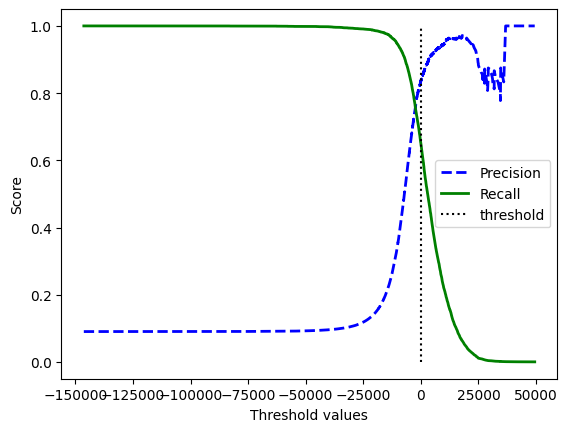

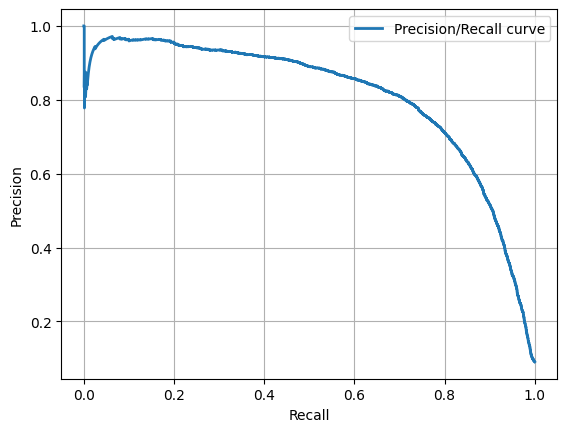

In [12]:
# The Precision/Recall Trade-off
# Повышение recall уменьшает количество пропущенных
# positive-объектов (FN), но обычно увеличивает число ложных срабатываний
# (FP), из-за чего падает precision. Повышение precision уменьшает количество
# ложных  positive-предсказаний, но модель становится строже и начинает
# пропускать больше настоящих positive-объектов, снижая recall.
# (по книге мы крутим threshold меняя эти Precision/Recall)
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# X0 = 5, X1 = 0
scores_for_five = sgd_clf.decision_function([X[0]])
scores_for_not_five = sgd_clf.decision_function([X[1]])
print("Scores for 5", scores_for_five)  # сильный positive
print("Scores for 0", scores_for_not_five)  # сильный negative
threshold = 0
print("It's five?", scores_for_five > threshold)
print("It's five?", scores_for_not_five > threshold)
# SGDClassifier uses a threshold equal to 0

# Возврат scores вместо predictions
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)
print(y_scores)

# y_true реальные ответы
# y_scores scores модели
# и вычисляет: precision,recall для множества разных threshold.
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Визуально отобразим (график thresholds относительно precisions и recalls)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.xlabel("Threshold values") # возможные пороги для decision_function score
plt.ylabel("Score") # значения precision и recall
plt.legend()
plt.show()
# At this threshold value, precision is near 90% and recall is around 50%
#             ↑
#             |  precision ≈ 0.9
#             |
#-------------|----------------
#             |
#             |  recall ≈ 0.5
#             ↓
#         threshold=3000

# график precision непосредственно относительно recall.
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()
# Recall маленький precision почти 1, большой precision падает
# Если посмотреть на график где Recall 0.8, то там сильно начинаем терять точность (при повышении)
# Может лучше выбрать threshold ДО резкого обвала precision. (или можно взять где 0.6 так как более точный)

In [13]:
# Поиск желаемого precision. допустим 90 (в зависимости от требований)
# минимальный threshold, при котором precision становится ≥ 90%.
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(threshold_for_90_precision)

# Сделать предсказания но без classifier’s predict()
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
print(precision_score(y_train_5, y_train_pred_90))
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
print(recall_at_90_precision)
# 90% precision, 48% recall


3370.0194991439557
0.9000345901072293
0.4799852425751706


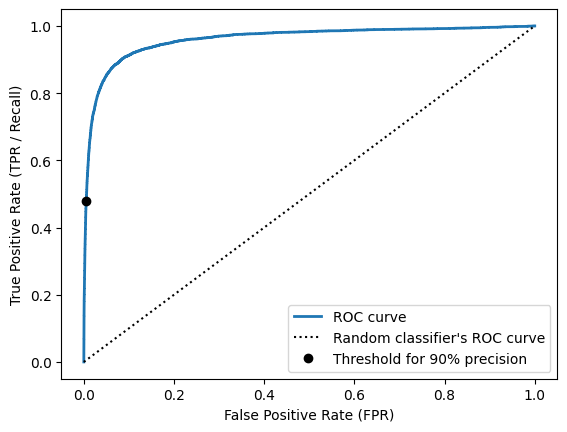

0.9604938554008616


In [17]:
# The ROC Curve (receiver operating characteristic)
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# False Positive Rate (FPR) какую долю настоящих negative объектов модель ошибочно пометила как positive.
# True Positive Rate (TPR) какую долю всех настоящих positive объектов модель смогла правильно найти.
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

# FPR к TPR
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.legend()
plt.show()
# слева True positive rate (recall)
# снизу false positive rate (fall out)
# Что означает эта точка по смыслу
# при threshold для 90% precision:
## модель:
## находит около 50% настоящих positive (TPR ≈ 0.5)
## ошибочно портит очень мало negative (FPR ≈ 0)
# Идеальная ROC:
# FPR = 0
# TPR = 1
# То есть:
# все positive нашли
# ни одного negative не испортили


# Пунктир ROC-кривую полностью случайного классификатора.
# Хороший классификатор находится как можно дальше 
# от этой линии (в сторону верхнего левого угла).
# Один из способов сравнивать классификаторы — 
# измерять площадь под кривой (AUC).
print(roc_auc_score(y_train_5, y_scores)) # 0.9 модель якобы хорошо отделяет positive от negative классы



y_probas_forest [[0.11 0.89]
 [0.99 0.01]]


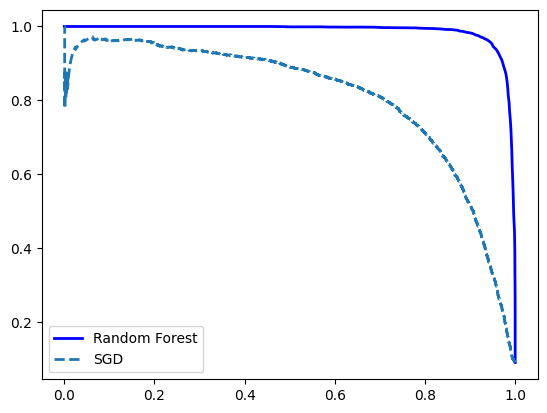

f1_score 0.9274509803921569
roc_auc_score 0.9983436731328145


In [ ]:
# Создаем RandomForestClassifier,
# чтобы сравнить его PR-кривую и F1-score с SGDClassifier
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

# RandomForest не имеет decision_function(),
# поэтому используем predict_proba()
#
# predict()         -> "это пятёрка"
# predict_proba()   -> "это пятёрка с вероятностью 92%"
#
# predict_proba() возвращает вероятность принадлежности
# объекта каждому классу:
#
# [P(не 5), P(5)]
#
# Эти вероятности будем использовать как score
# для построения Precision-Recall кривой
y_probas_forest = cross_val_predict(
    forest_clf, X_train, y_train_5, cv=3, method="predict_proba"
)

print("y_probas_forest", y_probas_forest[:2])

# пример вывода:
#
# [[0.11, 0.89]
#  [0.99, 0.01]]
#
# первое изображение:
# 0.11 -> вероятность "не 5"
# 0.89 -> вероятность "5"
# => модель на 89% уверена, что это пятёрка
#
# второе изображение:
# 0.99 -> вероятность "не 5"
# 0.01 -> вероятность "5"
# => модель на 99% уверена, что это не пятёрка

# Берем только столбец положительного класса ("5")
# : -> взять все строки
# 1 -> взять столбец с индексом 1 (вероятность класса "5")
#
# получим:
# [0.89, 0.01, ...]
y_scores_forest = y_probas_forest[:, 1]

# Передаем:
# y_train_5 -> реальные ответы
# y_scores_forest -> уверенность модели
#
# Функция строит зависимость Precision/Recall
# при изменении порога уверенности
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest
)

# Можно калибровать вероятности через
# CalibratedClassifierCV
#
# До:
# модель говорит 55%
# реальность 94%
#
# После:
# модель говорит 92%
# реальность 94%

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.legend()
plt.show()

# Посмотре на график RandomForestClassifier’s PR намного лучше чем
# SGDClassifier’s . RandomForestClassifier’s намного ближе к верху вправо
# Также F1 и ROC auc у него лучше

y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # positive proba ≥ 50%
print("f1_score",f1_score(y_train_5, y_train_pred_forest)) # 0.927450980392156 , а было 0.7325171197343847
print("roc_auc_score", roc_auc_score(y_train_5, y_scores_forest)) # 0.9983436731328145 , а было 0.9604938554008616

## Сводка
#### binary classifier — "5 или не 5"

сначала упростили задачу: не угадываем все 10 цифр, а только "это пятёрка или нет". сделали boolean mask `y_train_5 = y_train == "5"` и обучили `SGDClassifier`.

---

#### почему accuracy — плохая метрика

`DummyClassifier` (всегда говорит "не 5") даёт 90% accuracy — потому что пятёрок всего ~10% от датасета. класс несбалансированный, accuracy врёт.

---

#### confusion matrix

```
[[TN, FP],
 [FN, TP]]
```

- **TN** — правильно сказал "не 5"
- **TP** — правильно нашёл пятёрку
- **FP** — назвал пятёркой, а это не 5
- **FN** — пропустил настоящую пятёрку

---

#### precision & recall & f1

- `precision = TP / (TP + FP)` — насколько чисто предсказывает ("когда говорит 5, права ли?")
- `recall = TP / (TP + FN)` — сколько настоящих пятёрок находит
- `f1` — гармоническое среднее двух, плохой если хотя бы одна метрика плохая

аналогия с сетью: high recall — ловит всю рыбу но и мусор, high precision — только хорошая рыба но часть уплыла.

---

#### precision/recall trade-off

sgd использует threshold = 0 (score из `decision_function`). повышаешь threshold → precision растёт, recall падает. можно вручную найти нужный threshold — например при 90% precision recall упал до ~48%.

---

#### roc curve

строит fpr (ложные positive среди всех negative) vs tpr (recall). идеал: fpr=0, tpr=1 (верхний левый угол). площадь под кривой (auc) — чем ближе к 1, тем лучше. sgd auc ≈ 0.96.

---

#### randomforestclassifier vs sgdclassifier

forest не имеет `decision_function()` → используем `predict_proba()` → берём `[:, 1]` (вероятность класса "5").

| метрика | sgd | forest |
|---|---|---|
| f1 | 0.73 | **0.93** |
| roc auc | 0.96 | **0.998** |

pr-кривая forest намного ближе к верхнему правому углу. forest выиграл по всем метрикам.

---


In [5]:
# Multiclass Classification

# Цель: распознать одну цифру из 10 (0-9)
# Проблема: SVM и подобные алгоритмы — бинарные (binary = два варианта, да/нет)
# Решение: собираем много бинарных "да/нет" → агрегируем → один ответ

# OvR (One-vs-Rest)
# N бинарных классификаторов, каждый: "это мой класс или нет?"
# MNIST: 10 классификаторов (0-vs-rest, 1-vs-rest ... 9-vs-rest)
# Предсказание: берем класс с максимальным score → одна цифра
#   "5?" -> 4.8  ✓
#   "1?" -> 0.3
#   "0?" -> -2.1

# OvO (One-vs-One)
# Бинарный классификатор на каждую пару: 0v1, 0v2 ... 8v9
# MNIST: N*(N-1)/2 = 10*9/2 = 45 пар
# (делим на 2 — пара (0,1) и (1,0) одинаковая)
# Предсказание: "дуэли", побеждает класс с наибольшим числом побед → одна цифра

# OvR  — меньше моделей, проще
# OvO  — больше моделей, но SVM-подобные алгоритмы
#         обучаются быстрее на маленьких выборках

from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
# Берем только 2000 потому что может занять много времени
svm_clf.fit(X_train[:2000], y_train[:2000]) # y_train, not y_train_5

# X0 = 5, X1 = 0
print("predicted digit for sample X[0]:", svm_clf.predict([X[0]]))
print("predicted digit for sample X[1]:", svm_clf.predict([X[1]]))

# Getting a score
some_digit_scores = svm_clf.decision_function([X[0]])
print(some_digit_scores.round(2)) # Наибольший 9.3, это как раз и означает цифру 5!

class_id = some_digit_scores.argmax()
print("class with highest score for X[0]:", svm_clf.classes_[class_id])

# Список классов и рекомендация чтения по label вместо самого значения
print("classes" ,svm_clf.classes_)
print("a class by class id:",svm_clf.classes_[class_id])

predicted digit for sample X[0]: ['5']
predicted digit for sample X[1]: ['0']
[[ 3.79  0.73  6.06  8.3  -0.29  9.3   1.75  2.77  7.21  4.82]]
class with highest score for X[0]: 5
classes ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
a class by class id: 5


In [6]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
# Force use one-versus-one or on-versus-the-rest

# По дефолту SVC  использует OvO (45 дуэлей)
# Но можно принудительно OvR (10 классификаторов)

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])
print("OvR forced", ovr_clf.predict([X[0]]))
print(len(ovr_clf.estimators_))

# Ранее мы уже брали SGDClassifier, но использовали его только для пятерок
# sgd_clf.fit(X_train, y_train_5)
# Сейчас мы попробуем на всем трейне и дадим лейблы как y_train,
# то есть все цифры и не только 5

# Тут идет речь о том что sgd по дефолту юзает OvR
# Training an SGDClassifier on a multiclass dataset and usting it to make predictions
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
# Тут должен был предсказать 5
print("sgd predict", sgd_clf.predict([X[0]]))  # Но предсказал 3
# Посмотрим scores
print("sgd scores", sgd_clf.decision_function([X[0]]).round())
# А теперь сделаем оценку
# Пояснение к n_jobs ; n_jobs=-2 все ядра кроме одного
print("evaluate", cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-2))
# Мы получаем оценку как 85% процентов на всех test(разбитый train) folds
# 85%+ неплохо — random classifier дал бы только 10% (1 из 10 цифр)
# Но можно лучше — scaling поднимает accuracy до 89%+
# Но если пойти проще, то можно заскейлить инпуты (scaling the inputs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
print(
    "evalute after scaling",
    cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-2),
)


OvR forced ['5']
10
sgd predict ['3']
sgd scores [[-31893. -34420.  -9531.   1824. -22320.  -1386. -26189. -16148.  -4604.
  -12051.]]
evaluate [0.87365 0.85835 0.8689 ]
evalute after scaling [0.8983 0.891  0.9018]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


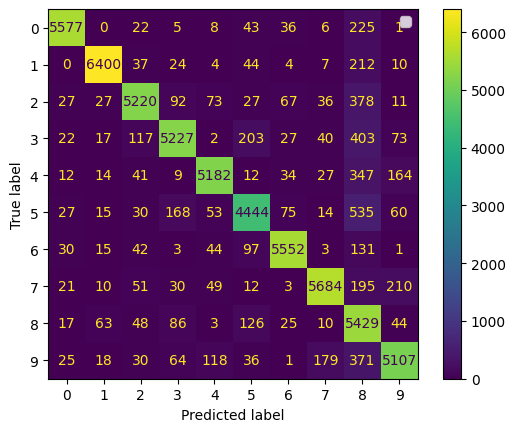

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


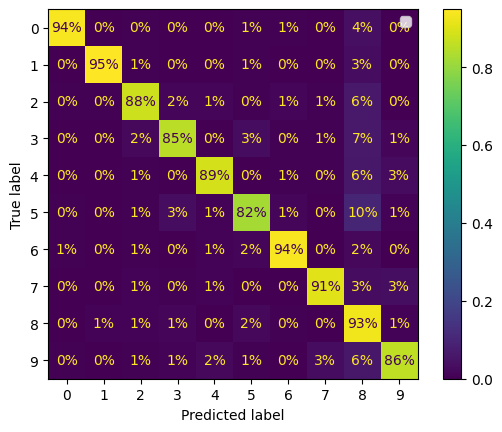

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


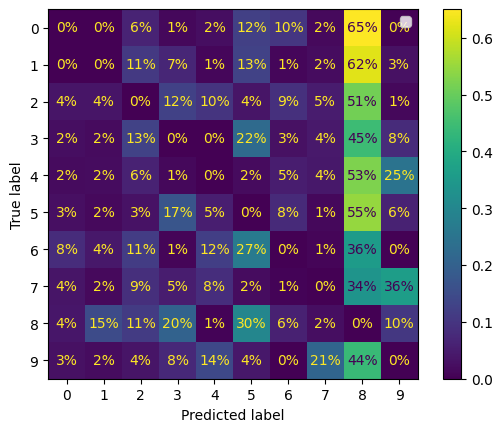

In [ ]:
# Error Analysis
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt


# Using a confusion matrix

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.legend()
plt.show()

# строка 5 столбец 5 выглядит немного темнее, чем остальные
# Означает что модель допустила больше ошибок, чем у остальных 
# (либо просто меньше пятерок в датасете)
# Поэтому нужно нормализировать матрицу ошибок, разделив каждое значение на
# общее кол-во изображений соответствующего (истинного) класса, то есть на сумму
# элементов строки. Это можно сделать с помощью  normalize="true"
# .0% проценты без десятичных знаков 82.4% -> 82%

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, normalize="true", values_format=".0%"
)
plt.legend()
plt.show()

# 82% процента пятерок классифицированы верно
# основных ошибки с пятерками(5), это то что мы их определяем как восьмерки(8)
# 10% на все пятерки(5), но только 2% восьмерок(8) мы 
# неправильно определили как пять(5)

# Можно ошибки сделать более видимыми
# можно попробовать убрать влияние правильных предсказаний 
# (присвоить им нулевой вес). (putting zero weight on the correct predictions)

# Правильные предсказания → False → вес 0
# Ошибочные предсказания → True → вес 1
# остаются только ошибки
sample_weight = (y_train_pred != y_train)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
sample_weight=sample_weight,
normalize="true", values_format=".0%")
plt.legend()
plt.show()
# Столбец 8 очень яркий , что подтверждает, что ногие изображения были 
# ошибочно классифицированы как 8
# Нужно помнить о том что правильных ответов нет , так как мы их исключили
# Например 36% в строке №7 и столбце №9 на левой диаграмме , не означает 
# что 36% всех избрж цифры 7 были классифицир как 9 
# означает что среди всех ошибок с цифрой 7, 36% были ошибками типа "7 → 9".
# на самом деле 3% изобрж с цифрой 7 были ошибочно распознаны как 9 
# (видно на првой диаграмме).

# -- пояснение
# 36% всех изображений цифры 7 были классифицированы как 9
# всего семёрок: 1000
# ошиблись как 9: 30
# (число ошибок 7→9) / (все изображения 7)
# 30 / 1000 = 3% (график 2 это видно)

# Среди всех ошибок на цифре 7, 36% были ошибками 7→9
# всего семёрок: 1000
# правильно: 917
# ошибок: 83
# из этих ошибок 30 были 7→9
# (число ошибок 7→9) / (все ошибки на 7)
# 30 / 83 ≈ 36%
# --

# еще можно нормализовать по стобцам , а не строкам normalize="pred"
# тогда получится как 3-10 по книге. Можно увидеть что 56% неправильно 
# классифицированных семёрок на самом деле были распознаны как девятки.
# normalize="true" → нормализация 
# по строкам → «из всех реальных цифр 7, куда они попали?»
# normalize="pred" → нормализация 
# по столбцам → «из всех предсказанных цифр 9, что это было на самом деле?»

# Пример к normalize="true"  и normalize="pred"
# (Матрица)
# Реальная 7 → предсказана как 7 : 970
# Реальная 7 → предсказана как 9 : 30
# Реальная 9 → предсказана как 9 : 500
# Реальная 8 → предсказана как 9 : 20
# Реальная 3 → предсказана как 9 : 10

# По строкам -- normalize="true" (Recall) Из всех реальных объектов 
# класса сколько нашли смогли найти
# # Из всех семерок:
# 97% -> стали 7
# 3% -> стали 9

# По столбцам (normalize="pred"): (Precision) на сколько точно
# Предсказанных 9 получилось:
# 500 + 30 + 20 + 10 = 560 предсказанных девяток
# Из всех предсказанных 9:
# 89% были настоящими 9
# 5% были 7
# 4% были 8
# 2% были 3
# 11% среди предсказанных 9 было 11% ложных девяток
#  (ложные девятки / все предсказанные девятки * 100) 

# Как улучшить:
# 1) собрать больше 8 где они похоже на 8, но они не явлюятся ими
# 2) closed loops (алгоритм подсчёта замкнутых контуров)
# у 8 два замкнутых круга, у 6 один, у 5 ни одного


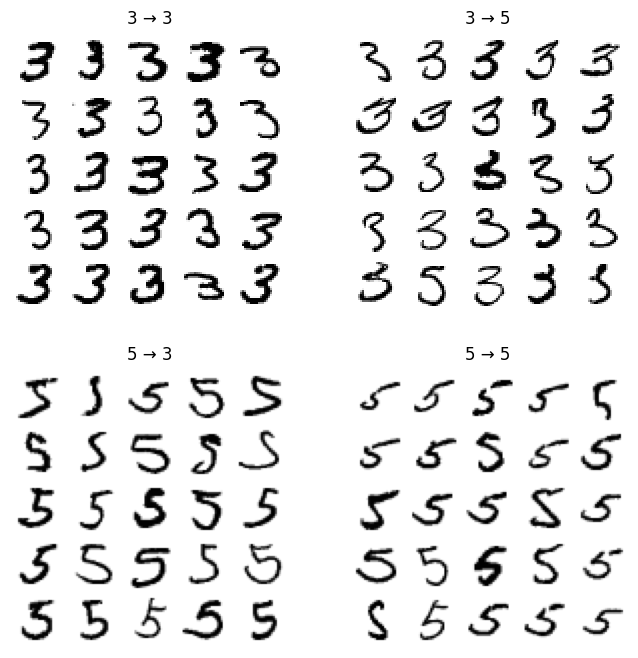

In [ ]:
# давайте построим примеры цифр 3 и 5 в стиле матрицы ошибок
import matplotlib.pyplot as plt
import numpy as np

cl_a, cl_b = '3', '5'

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

def plot_digits(instances, images_per_row=5):
    size = 28

    images = [img.reshape(size, size) for img in instances[:25]]

    rows = []
    for i in range(0, len(images), images_per_row):
        row = np.concatenate(images[i:i+images_per_row], axis=1)
        rows.append(row)

    image = np.concatenate(rows, axis=0)

    plt.imshow(image, cmap="binary")
    plt.axis("off")

plt.figure(figsize=(8,8))

plt.subplot(221)
plot_digits(X_aa)
plt.title("3 → 3")

plt.subplot(222)
plot_digits(X_ab)
plt.title("3 → 5")

plt.subplot(223)
plot_digits(X_ba)
plt.title("5 → 3")

plt.subplot(224)
plot_digits(X_bb)
plt.title("5 → 5")

plt.show()


# 3 и 5 сильно похожи, один из способов решить это
# Должны быть уже данные центированные и не сильно повернуты
# Если угол поворота сильный, придется предсказывать угол поворота
# Поэтому было бы неплохо добавить слегка смещенные и повернутые версии
# Такой метод называется аугментацией данных (data augmentation).

In [ ]:
# Multilabel Classification
import numpy as np
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

# X0 = 5, X1 = 0
print(knn_clf.predict([X[0]]))
print(knn_clf.predict([X[1]]))

# y_multilabel содержит 2 лейбла для каждого изображение 
# говорит о том что число больше или 7,8,9
# а второе говорит число нечётное значение ли
# использует KNeighborsClassifier так как он поддерживает multilabel

# Измерим F1 на все лейблы
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
# Для multilabel часто используют F1-score для каждой метки и усредняют результат.
# average="macro" — все метки одинаково важны
# average="weighted" — частые классы получают больший вес
print(f1_score(y_multilabel, y_train_knn_pred, average="macro"))
# 0.9764102655606048 в среднем хорошо предсказывает
# тут две метки large и odd
# Под капотом считает для каждой , а потом берет обычное среднее
# F1_large = 0.98
# F1_odd = 0.97
# macro_F1 = (0.98 + 0.97) / 2

# Проблема SVC он не поддерживает multilabel
# Тогда можно обучить отдельную модель для каждой метки
# Но тогда модели не знают о предсказаниях друг друга.
# ClassifierChain решает это:
# каждая следующая модель получает исходные данные и предсказания предыдущих моделей
# Так можно учитывать зависимости между метками.
# Например:
# большие цифры (7,8,9) чаще нечётные
# информация о “large” помогает предсказывать “odd”
chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])
print(chain_clf.predict([X[0]]))
# [[0. 1.]] тоже самое что и [[False  True]] при KNeighborsClassifier

[[False  True]]
[[False False]]
0.9764102655606048
[[0. 1.]]


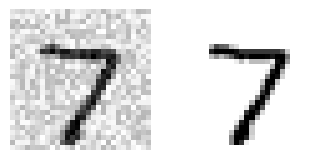

In [33]:
# Multioutput Classification
import numpy as np
import matplotlib.pyplot as plt


# Обычная классификация:
# картинка -> 1 ответ
# Multioutput Теперь модель выдаёт сразу много ответов:
# 1 объект -> много outputs
# В этом примере:
# output = каждый пиксель изображения всего 784 outputs

# Для нашей задачи попробуем предсказать верные пиксели
# Но для примера мы их загрязним шумом

rng = np.random.default_rng(seed=42)
# случайные числа 0-99 формы (кол-во изображений, 784 пикселя)
noise_train = rng.integers(0, 100, (len(X_train), 784))
# оригинальные пиксели  X = [10, 50, 200]
# случайный шум noise = [3, 20, 15]
# поэлементное сложение X_mod = X + noise
# результат [13, 70, 215]
X_train_mod = X_train + noise_train
noise_test = rng.integers(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test
y_train_mod = X_train
y_test_mod = X_test


def plot_digit(image_data, ax):
    image = image_data.reshape(28, 28)
    ax.imshow(image, cmap="binary")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(4, 2))

plot_digit(X_test_mod[0], axes[0])
plot_digit(y_test_mod[0], axes[1])

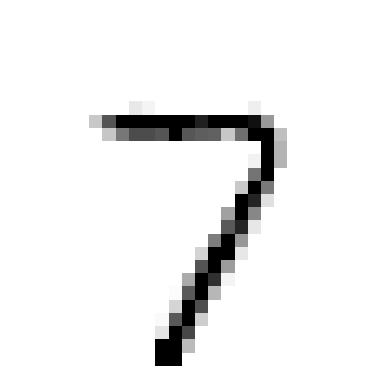

In [34]:
def simple_plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
simple_plot_digit(clean_digit)
